In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

### All MODE TRIP

In [2]:
all_mode = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'MA_trips' ) 

In [3]:
all_mode

,Year_Month,Card_type,Travel_Mode,Trip
0,2016-07-01,Adult,Bus,13146432.0
1,2016-07-01,Child/Youth,Bus,1079640.0
2,2016-07-01,Concession,Bus,1845322.0
3,2016-07-01,Employee,Bus,64989.0
4,2016-07-01,Free Travel,Bus,25228.0
...,...,...,...,...
6391,NaT,1910,NaN,NaN
6392,NaT,51793,NaN,NaN
6393,NaT,140387,NaN,NaN
6394,NaT,10143,NaN,NaN


In [4]:
# Convert to datetime format
all_mode['date'] = pd.to_datetime(all_mode['Year_Month'], format= '%b-%Y')

In [5]:
all_mode['Year'] = all_mode['date'].dt.year.round(0)
all_mode['Month'] = all_mode['date'].dt.month_name()

In [6]:
all_mode

,Year_Month,Card_type,Travel_Mode,Trip,date,Year,Month
0,2016-07-01,Adult,Bus,13146432.0,2016-07-01,2016.0,July
1,2016-07-01,Child/Youth,Bus,1079640.0,2016-07-01,2016.0,July
2,2016-07-01,Concession,Bus,1845322.0,2016-07-01,2016.0,July
3,2016-07-01,Employee,Bus,64989.0,2016-07-01,2016.0,July
4,2016-07-01,Free Travel,Bus,25228.0,2016-07-01,2016.0,July
...,...,...,...,...,...,...,...
6391,NaT,1910,NaN,NaN,NaT,NaN,NaN
6392,NaT,51793,NaN,NaN,NaT,NaN,NaN
6393,NaT,140387,NaN,NaN,NaT,NaN,NaN
6394,NaT,10143,NaN,NaN,NaT,NaN,NaN


In [7]:
cols= ['Year', 'Month', 'Travel_Mode', 'Card_type', 'Trip']
new_mode = all_mode[cols]

In [8]:
new_mode = new_mode.dropna()

In [9]:
new_mode['Year'].value_counts()

Year
2024.0    780
2020.0    751
2023.0    747
2022.0    739
2021.0    736
2019.0    712
2018.0    577
2025.0    508
2017.0    499
2016.0    231
Name: count, dtype: int64

In [10]:
new_mode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6280 entries, 0 to 6279
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         6280 non-null   float64
 1   Month        6280 non-null   object 
 2   Travel_Mode  6280 non-null   object 
 3   Card_type    6280 non-null   object 
 4   Trip         6280 non-null   float64
dtypes: float64(2), object(3)
memory usage: 294.4+ KB


In [11]:
new_mode

,Year,Month,Travel_Mode,Card_type,Trip
0,2016.0,July,Bus,Adult,13146432.00
1,2016.0,July,Bus,Child/Youth,1079640.00
2,2016.0,July,Bus,Concession,1845322.00
3,2016.0,July,Bus,Employee,64989.00
4,2016.0,July,Bus,Free Travel,25228.00
...,...,...,...,...,...
6275,2024.0,September,Bus,UNKNOWN,78.00
6276,2024.0,September,Ferry,UNKNOWN,5.00
6277,2024.0,September,Light Rail,UNKNOWN,1.00
6278,2024.0,September,Metro,UNKNOWN,3.52


In [12]:
new_mode.to_csv('all_mode.csv')

In [13]:
new_mode.columns

Index(['Year', 'Month', 'Travel_Mode', 'Card_type', 'Trip'], dtype='object')

In [14]:
# sum annual
annual = new_mode.groupby(['Year', 'Travel_Mode'], as_index= False)['Trip'].sum()

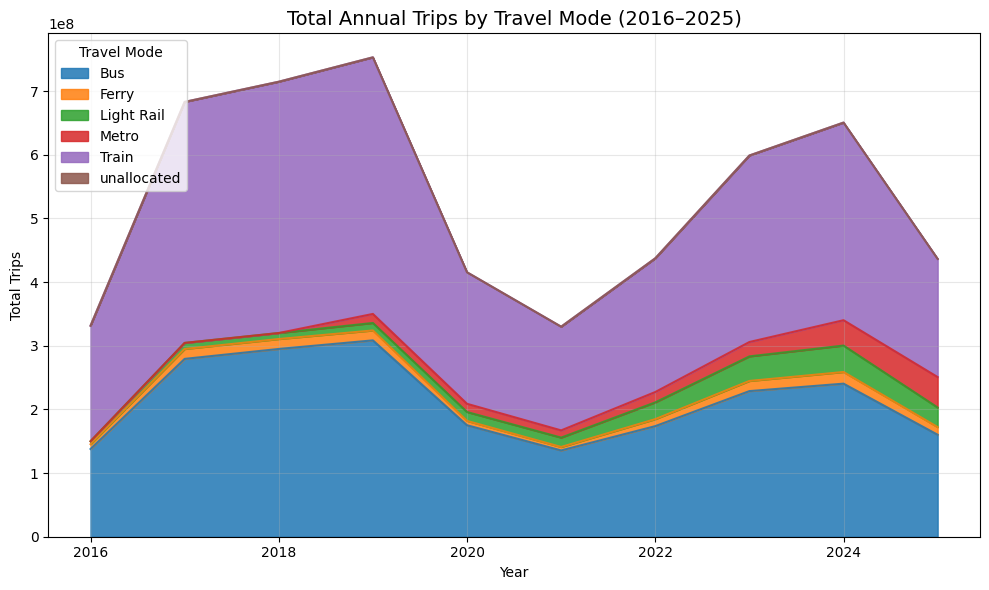

In [15]:
# 2Pivot to wide format
pivot = annual.pivot(index='Year', columns='Travel_Mode', values='Trip').fillna(0)

#  Plot stacked area chart
pivot.plot(kind='area', stacked=True, figsize=(10,6), alpha=0.85)

plt.title('Total Annual Trips by Travel Mode (2016–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Trips')
plt.legend(title='Travel Mode', loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

### Customer satisfaction

In [16]:
csi = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'Cus_CSI') 

In [17]:
csi['Metric'].value_counts()
csi

,year,Mode,Service-driver,Services_attribute,Metric,CSI (average)
0,2016,Ferry,Overall,How satisfied are you with this service,% satisfied,0.974031
1,2016,Ferry,Timeliness,This ferry turning up on time,% satisfied,0.965167
2,2016,Ferry,Timeliness,Frequency of this ferry service,% satisfied,0.868050
3,2016,Ferry,Timeliness,Journey time given the distance travelled,% satisfied,0.956768
4,2016,Ferry,Timeliness,Time to connect to other transport services,% satisfied,0.929703
...,...,...,...,...,...,...
171,2016,Bus,Information,Availability of information about service delays,% dissatisfied,0.123546
172,2016,Bus,Information,"Ease of finding info (routes, stops, timetables)",% dissatisfied,0.076901
173,2016,Bus,Customer Service,Willingness of bus staff to help,% dissatisfied,0.027521
174,2016,Bus,Customer Service,Knowledge of bus staff,% dissatisfied,0.018001


In [18]:
csi.columns = ['Year', 'Travel Mode', 'Service Driver','Service Attribute','Metrics','Customer Satisfaction Index']

In [19]:
csi['Service Driver'].value_counts()

Service Driver
Comfort              34
Timeliness           24
Information          24
Accessibility        18
Customer Service     18
Safety & Security    16
Ticketing            12
Convenience          12
Cleanliness          12
Overall               6
Name: count, dtype: int64

In [20]:
# Filter metric satisfaction
csi = csi[csi['Metrics'] == '% satisfied']
# Group by Driver, Attribute, and Mode
agg = (
    csi.groupby(['Service Driver', 'Service Attribute', 'Travel Mode'], as_index=False)
    ['Customer Satisfaction Index'].mean()
)

# Example filter: choose one driver (e.g. Timeliness)
driver_name = "Customer Service"
agg_driver = agg[agg['Service Driver'] == driver_name]


In [21]:
# This code only executed just one time
pivot = agg_driver.pivot(
    index='Service Attribute',
    columns='Travel Mode',
    values='Customer Satisfaction Index'
)

In [22]:
pivot

Travel Mode,Bus,Ferry,Train
Service Attribute,,,
Knowledge of bus staff,0.935012,NaN,NaN
Knowledge of ferry staff,NaN,0.935048,NaN
Knowledge of rail staff,NaN,NaN,0.838655
Presentation of bus staff,0.961041,NaN,NaN
Presentation of ferry staff,NaN,0.953815,NaN
Presentation of rail staff,NaN,NaN,0.864281
Willingness of bus staff to help,0.929565,NaN,NaN
Willingness of ferry staff to help,NaN,0.941765,NaN
Willingness of rail staff to help,NaN,NaN,0.838037


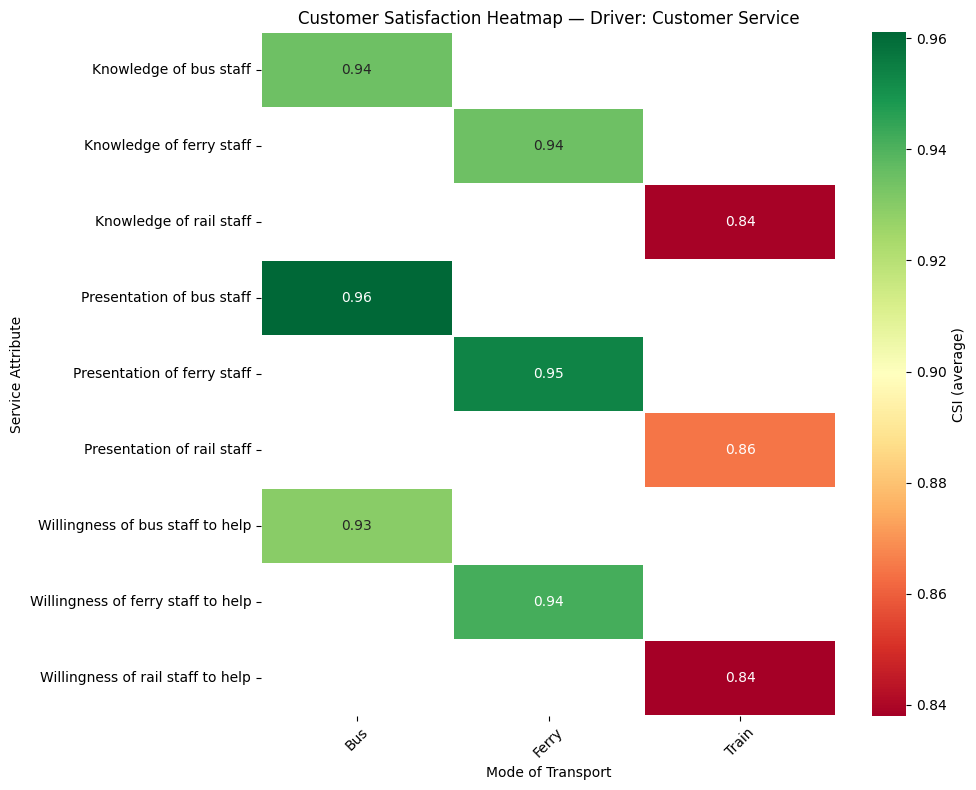

In [23]:
# create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap='RdYlGn',   # Red (low) → Yellow → Green (high)
    linewidths=0.3,
    cbar_kws={'label': 'CSI (average)'}
)
plt.title(f"Customer Satisfaction Heatmap — Driver: {driver_name}")
plt.xlabel("Mode of Transport")
plt.ylabel("Service Attribute")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

In [24]:
# save csi data file
csi.to_csv('Customer Satisfaction.csv')

### Affordability

In [25]:
afford = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'Affordability') 

In [26]:
afford.isnull().sum()

Year_Month                  0
Card Type                   0
Travel Mode                 0
Distance Band               0
Fare_nominal (Peak time)    0
CPI                         0
Fare_real (Peaktime)        0
weekday-cap                 0
weekly-cap                  0
dtype: int64

In [27]:
afford.to_csv('affordability.csv')

### Hourly Opal Trip

In [28]:
peak = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'Hourly opal Trips') 

In [29]:
peak['Year'] = 2023
peak = peak.drop(columns= 'Year')

In [51]:
peak

,Travel Time,Mode,Trips,Year,Month
0,00:00:00,Train,51400.0,2023,November
1,01:00:00,Train,2800.0,2023,November
2,02:00:00,Train,2600.0,2023,November
3,03:00:00,Train,26600.0,2023,November
4,04:00:00,Train,301000.0,2023,November
...,...,...,...,...,...
844,03:00:00,0.958333,34000.0,2023,November
850,09:00:00,0.958333,264200.0,2023,November
851,10:00:00,0.958333,160000.0,2023,November
852,11:00:00,0.958333,5200.0,2023,November


In [31]:
# Remove space in colm name
peak = peak.melt(id_vars= 'Travel Time', var_name= 'Mode', value_name= 'Trips')

In [32]:
peak['Year'] = 2023
peak['Month'] = 'November'

In [33]:
peak.dropna(inplace= True)

In [ ]:
mask = peak["Trips"].astype(str).str.replace(",", "", regex=False).str.isnumeric()



In [56]:
df

,Travel Time,Mode,Trips,Year,Month


In [58]:
peak.to_excel('Peak_hour.xlsx')

### Method of travel to work and worked at home 

In [35]:
method = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'LGA  Method of travel to work') 

In [36]:
method['Year'] = 2021
cols = ['Year','LGAs', 'Distance from Sydney CBD (km)', 'Public transport use (%)']

In [37]:
travel_method = method[cols]

In [38]:
travel_method.to_csv('LGA.csv')

### On-time performance

In [39]:
on_time = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'On-time performance %') 

In [40]:
ont= on_time.melt(id_vars= 'Operator', var_name= 'Date', value_name= 'On-time percentage')

In [41]:
ont['date'] = pd.to_datetime(ont['Date'], format= '%b-%Y')

In [42]:
ont['Year'] = ont['date'].dt.year
ont['Month'] = ont['date'].dt.month_name()

In [43]:
get_cols = ['Year', 'Month', 'Operator','On-time percentage']
ont = ont[get_cols]

### lGA household travel

In [44]:
LGA = pd.read_excel('Mix_dataset.xlsx', sheet_name= 'LGA Household travel mode ') 

In [45]:
LGA.to_csv('household_travel.csv')